In [56]:
import pandas as pd
import numpy as np

In [57]:
#loading tables
users=pd.read_excel("User_Retention_Portfolio_Dataset.xlsx",sheet_name="Users")
activity=pd.read_excel("User_Retention_Portfolio_Dataset.xlsx",sheet_name=1)
transactions=pd.read_excel("User_Retention_Portfolio_Dataset.xlsx",sheet_name=2)
support=pd.read_excel("User_Retention_Portfolio_Dataset.xlsx",sheet_name=3)
marketing=pd.read_excel("User_Retention_Portfolio_Dataset.xlsx",sheet_name=4)
subscription=pd.read_excel("User_Retention_Portfolio_Dataset.xlsx",sheet_name=5)

In [58]:
tables = {
    "users": users,
    "activity": activity,
    "transactions": transactions,
    "support": support,
    "marketing": marketing,
    "subscription": subscription
}

for name, df in tables.items():
    print("\n", "="*50)
    print(name)
    print("Shape:", df.shape)
    print("Duplicates:", df.duplicated().sum())
    print("Null values:")
    print(df.isnull().sum())


users
Shape: (5000, 12)
Duplicates: 0
Null values:
user_id                   0
signup_date               0
country                   0
state                     0
age                       0
gender                    0
device                    0
acquisition_channel       0
subscription_type         0
churned                   0
churn_date             3394
age_group                 0
dtype: int64

activity
Shape: (150000, 8)
Duplicates: 0
Null values:
activity_id        0
user_id            0
activity_date      0
session_minutes    0
pages_viewed       0
login_count        0
feature_used       0
device             0
dtype: int64

transactions
Shape: (50000, 8)
Duplicates: 0
Null values:
transaction_id      0
user_id             0
transaction_date    0
amount              0
payment_method      0
status              0
coupon_code         0
refund              0
dtype: int64

support
Shape: (18000, 8)
Duplicates: 0
Null values:
ticket_id           0
user_id             0
created_date    

In [59]:
for i, j in tables.items():
    print(i, "->", j.columns[0])

users -> user_id
activity -> activity_id
transactions -> transaction_id
support -> ticket_id
marketing -> campaign_id
subscription -> history_id


In [60]:
print("Primary_Keys","\n")
for i,j in tables.items():
    print(i,":",j.iloc[:,0].nunique())

Primary_Keys 

users : 5000
activity : 150000
transactions : 50000
support : 18000
marketing : 5000
subscription : 20000


In [61]:
#checking relationship
print(activity["user_id"].isin(users["user_id"]).mean())
print(transactions["user_id"].isin(users["user_id"]).mean())
print(support["user_id"].isin(users["user_id"]).mean())
print(subscription["user_id"].isin(users["user_id"]).mean())

1.0
1.0
1.0
1.0


In [62]:
# date range
print("User signup:")
print(users["signup_date"].min(), users["signup_date"].max(),"\n")

print("Activity:")
print(activity["activity_date"].min(), activity["activity_date"].max(),"\n")

print("Transactions:")
print(transactions["transaction_date"].min(), transactions["transaction_date"].max(),"\n")

User signup:
2024-01-01 00:00:00 2024-12-31 00:00:00 

Activity:
2024-01-01 00:00:00 2025-06-29 00:00:00 

Transactions:
2024-01-02 00:00:00 2025-06-29 00:00:00 



In [63]:

users["signup_month"]=users["signup_date"].dt.to_period("M")

users[["user_id","signup_date","signup_month"]].head()

,user_id,signup_date,signup_month
0,1,2024-11-23,2024-11
1,2,2024-08-04,2024-08
2,3,2024-11-28,2024-11
3,4,2024-05-22,2024-05
4,5,2024-06-25,2024-06


In [64]:
#activiry_cohort
activity_cohort=activity.merge(users[["user_id","signup_month"]],on="user_id",how="inner")
activity_cohort.head()

,activity_id,user_id,activity_date,session_minutes,pages_viewed,login_count,feature_used,device,signup_month
0,1,826,2024-02-18,10,13,3,Browse,Android,2024-01
1,5620,826,2024-06-17,14,10,1,Profile,Android,2024-01
2,8418,826,2024-05-02,22,20,3,Watch,Android,2024-01
3,10032,826,2024-05-18,10,23,3,Watch,Android,2024-01
4,10585,826,2024-07-08,6,4,4,Profile,Android,2024-01


In [65]:
activity_cohort["activity_month"]=activity_cohort["activity_date"].dt.to_period("M")
activity_cohort.head()

,activity_id,user_id,activity_date,session_minutes,pages_viewed,login_count,feature_used,device,signup_month,activity_month
0,1,826,2024-02-18,10,13,3,Browse,Android,2024-01,2024-02
1,5620,826,2024-06-17,14,10,1,Profile,Android,2024-01,2024-06
2,8418,826,2024-05-02,22,20,3,Watch,Android,2024-01,2024-05
3,10032,826,2024-05-18,10,23,3,Watch,Android,2024-01,2024-05
4,10585,826,2024-07-08,6,4,4,Profile,Android,2024-01,2024-07


In [66]:
activity_cohort["cohort_month"]=((activity_cohort["activity_month"].dt.year - activity_cohort["signup_month"].dt.year)*12 + (activity_cohort["activity_month"].dt.month - activity_cohort["signup_month"].dt.month))
activity_cohort.head()

,activity_id,user_id,activity_date,session_minutes,pages_viewed,login_count,feature_used,device,signup_month,activity_month,cohort_month
0,1,826,2024-02-18,10,13,3,Browse,Android,2024-01,2024-02,1
1,5620,826,2024-06-17,14,10,1,Profile,Android,2024-01,2024-06,5
2,8418,826,2024-05-02,22,20,3,Watch,Android,2024-01,2024-05,4
3,10032,826,2024-05-18,10,23,3,Watch,Android,2024-01,2024-05,4
4,10585,826,2024-07-08,6,4,4,Profile,Android,2024-01,2024-07,6


In [67]:
#unique active users
cohort_data=activity_cohort.groupby(["signup_month","cohort_month"])["user_id"].nunique().reset_index().rename(columns={"user_id":"active_users"})
cohort_data

,signup_month,cohort_month,active_users
0,2024-01,0,351
1,2024-01,1,419
2,2024-01,2,420
3,2024-01,3,421
4,2024-01,4,422
...,...,...,...
79,2024-12,2,426
80,2024-12,3,427
81,2024-12,4,427
82,2024-12,5,427


In [68]:
retention_matrix = cohort_data.pivot(
    index="signup_month",
    columns="cohort_month",
    values="active_users"
)
retention_matrix 

cohort_month,0,1,2,3,4,5,6
signup_month,,,,,,,
2024-01,351,419,420,421,422,420,317
2024-02,336,397,397,397,396,401,294
2024-03,366,438,439,437,435,435,298
2024-04,334,411,410,410,411,407,290
2024-05,366,442,442,442,440,442,306
2024-06,302,378,380,378,380,381,270
2024-07,314,378,381,383,383,383,261
2024-08,370,447,450,446,448,449,328
2024-09,309,388,390,391,390,389,306


In [112]:
cohort_size = (
    users.groupby("signup_month")["user_id"]
    .nunique()
)
cohort_size

signup_month
2024-01    422
2024-02    401
2024-03    440
2024-04    413
2024-05    443
2024-06    382
2024-07    384
2024-08    452
2024-09    393
2024-10    420
2024-11    418
2024-12    432
Freq: M, Name: user_id, dtype: int64

In [113]:
retention_pct = retention_matrix.divide(
    cohort_size,
    axis=0
) * 100
retention_pct.round(2)

cohort_month,0,1,2,3,4,5,6
signup_month,,,,,,,
2024-01,83.18,99.29,99.53,99.76,100.00,99.53,75.12
2024-02,83.79,99.00,99.00,99.00,98.75,100.00,73.32
2024-03,83.18,99.55,99.77,99.32,98.86,98.86,67.73
2024-04,80.87,99.52,99.27,99.27,99.52,98.55,70.22
2024-05,82.62,99.77,99.77,99.77,99.32,99.77,69.07
2024-06,79.06,98.95,99.48,98.95,99.48,99.74,70.68
2024-07,81.77,98.44,99.22,99.74,99.74,99.74,67.97
2024-08,81.86,98.89,99.56,98.67,99.12,99.34,72.57
2024-09,78.63,98.73,99.24,99.49,99.24,98.98,77.86


In [114]:
print("Total users:", users["user_id"].nunique())
print("Users with activity:", activity["user_id"].nunique())
print(
    "Users without activity:",
    users["user_id"].nunique() - activity["user_id"].nunique()
)
print(activity["activity_date"].min())
print(activity["activity_date"].max())


Total users: 5000
Users with activity: 5000
Users without activity: 0
2024-01-01 00:00:00
2025-06-29 00:00:00


In [115]:
activity_count = (
    activity.groupby("user_id")
    .size()
    .describe()
)

activity_count


count    5000.000000
mean       30.000000
std         5.499932
min        12.000000
25%        26.000000
50%        30.000000
75%        34.000000
max        49.000000
dtype: float64

In [116]:
activity.groupby("user_id").size().value_counts().sort_index().head(20)

12      1
13      1
15      9
16     12
17     22
18     29
19     42
20     65
21     81
22    143
23    177
24    198
25    284
26    279
27    347
28    322
29    371
30    352
31    331
32    343
dtype: int64

In [117]:
activity.groupby("user_id")["activity_date"].agg(
    ["min", "max", "count"]
).head(10)


,min,max,count
user_id,,,
1,2024-11-26,2025-05-17,25
2,2024-08-16,2025-01-29,25
3,2024-12-05,2025-05-22,35
4,2024-05-26,2024-11-13,28
5,2024-06-25,2024-12-20,17
6,2024-06-05,2024-11-24,26
7,2024-02-12,2024-07-31,29
8,2024-04-29,2024-10-07,27
9,2024-08-25,2025-02-15,38


In [118]:
first_activity = (
    activity.groupby("user_id")["activity_date"]
    .min()
    .reset_index(name="first_activity_date")
)
first_activity.head(10)

,user_id,first_activity_date
0,1,2024-11-26
1,2,2024-08-16
2,3,2024-12-05
3,4,2024-05-26
4,5,2024-06-25
5,6,2024-06-05
6,7,2024-02-12
7,8,2024-04-29
8,9,2024-08-25
9,10,2024-07-24


In [119]:
first_activity["activation_month"] = (
    first_activity["first_activity_date"].dt.to_period("M")
)
first_activity["activation_month"].value_counts().sort_index()

first_activity.head(10)


,user_id,first_activity_date,activation_month
0,1,2024-11-26,2024-11
1,2,2024-08-16,2024-08
2,3,2024-12-05,2024-12
3,4,2024-05-26,2024-05
4,5,2024-06-25,2024-06
5,6,2024-06-05,2024-06
6,7,2024-02-12,2024-02
7,8,2024-04-29,2024-04
8,9,2024-08-25,2024-08
9,10,2024-07-24,2024-07


In [120]:
activity_activation = activity.merge(
    first_activity[["user_id", "activation_month"]],
    on="user_id",
    how="left"
)
activity_activation.head()

,activity_id,user_id,activity_date,session_minutes,pages_viewed,login_count,feature_used,device,activation_month
0,1,826,2024-02-18,10,13,3,Browse,Android,2024-02
1,2,4186,2024-03-12,15,9,3,Download,Web,2024-02
2,3,4139,2024-10-09,11,25,4,Download,Android,2024-05
3,4,3995,2024-10-07,600,1,4,Search,Web,2024-10
4,5,3040,2025-05-16,31,21,4,Browse,iOS,2024-12


In [121]:
activity_activation["activity_month"] = (
    activity_activation["activity_date"].dt.to_period("M")
)
activity_activation[["user_id", "activation_month", "activity_month"]].head(10)

,user_id,activation_month,activity_month
0,826,2024-02,2024-02
1,4186,2024-02,2024-03
2,4139,2024-05,2024-10
3,3995,2024-10,2024-10
4,3040,2024-12,2025-05
5,1781,2024-11,2024-12
6,1657,2024-03,2024-04
7,4064,2024-05,2024-10
8,3943,2024-05,2024-09
9,4951,2024-09,2024-12


In [122]:
activity_activation["cohort_month"] = (
    (activity_activation["activity_month"].dt.year -
     activity_activation["activation_month"].dt.year) * 12
    +
    (activity_activation["activity_month"].dt.month -
     activity_activation["activation_month"].dt.month)
)
activity_activation[["user_id", "activation_month", "activity_month", "cohort_month"]].head(20)

,user_id,activation_month,activity_month,cohort_month
0,826,2024-02,2024-02,0
1,4186,2024-02,2024-03,1
2,4139,2024-05,2024-10,5
3,3995,2024-10,2024-10,0
4,3040,2024-12,2025-05,5
5,1781,2024-11,2024-12,1
6,1657,2024-03,2024-04,1
7,4064,2024-05,2024-10,5
8,3943,2024-05,2024-09,4
9,4951,2024-09,2024-12,3


In [123]:
activation_cohort_data = (
    activity_activation
    .groupby(["activation_month", "cohort_month"])["user_id"]
    .nunique()
    .reset_index(name="active_users")
)
activation_cohort_data.head(15)

,activation_month,cohort_month,active_users
0,2024-01,0,351
1,2024-01,1,348
2,2024-01,2,349
3,2024-01,3,350
4,2024-01,4,351
5,2024-01,5,349
6,2024-01,6,247
7,2024-02,0,407
8,2024-02,1,405
9,2024-02,2,403


In [124]:
activation_retention_matrix = (
    activation_cohort_data
    .pivot(
        index="activation_month",
        columns="cohort_month",
        values="active_users"
    )
)
activation_retention_matrix

cohort_month,0,1,2,3,4,5,6
activation_month,,,,,,,
2024-01,351.0,348.0,349.0,350.0,351.0,349.0,247.0
2024-02,407.0,405.0,403.0,405.0,403.0,406.0,233.0
2024-03,429.0,427.0,426.0,425.0,424.0,421.0,226.0
2024-04,410.0,408.0,408.0,408.0,408.0,400.0,214.0
2024-05,445.0,443.0,443.0,443.0,443.0,442.0,231.0
2024-06,379.0,375.0,377.0,376.0,376.0,376.0,195.0
2024-07,394.0,391.0,390.0,393.0,393.0,388.0,196.0
2024-08,437.0,433.0,435.0,432.0,434.0,429.0,250.0
2024-09,392.0,388.0,389.0,389.0,390.0,381.0,224.0


In [125]:
activation_retention_pct = (
    activation_retention_matrix
    .divide(activation_retention_matrix[0], axis=0)
    * 100
)
activation_retention_pct.round(2)

cohort_month,0,1,2,3,4,5,6
activation_month,,,,,,,
2024-01,100.0,99.15,99.43,99.72,100.00,99.43,70.37
2024-02,100.0,99.51,99.02,99.51,99.02,99.75,57.25
2024-03,100.0,99.53,99.30,99.07,98.83,98.14,52.68
2024-04,100.0,99.51,99.51,99.51,99.51,97.56,52.20
2024-05,100.0,99.55,99.55,99.55,99.55,99.33,51.91
2024-06,100.0,98.94,99.47,99.21,99.21,99.21,51.45
2024-07,100.0,99.24,98.98,99.75,99.75,98.48,49.75
2024-08,100.0,99.08,99.54,98.86,99.31,98.17,57.21
2024-09,100.0,98.98,99.23,99.23,99.49,97.19,57.14


In [127]:
users["churned"].value_counts()

No     3394
Yes    1606
Name: churned, dtype: int64

In [128]:
#Transaction analysis
transactions.head()

,transaction_id,user_id,transaction_date,amount,payment_method,status,coupon_code,refund
0,1,4654,2024-08-06,99.99,UPI,Success,NEW10,No
1,2,2649,2024-12-24,9.99,Debit,Success,NONE,No
2,3,3731,2025-04-04,29.99,Card,Success,NONE,No
3,4,1546,2025-05-20,9.99,Card,Success,SAVE20,No
4,5,3435,2024-09-09,9.99,PayPal,Success,NONE,No


In [129]:
transactions["status"].value_counts()


Success    46988
Failed      3012
Name: status, dtype: int64

In [130]:
transactions["refund"].value_counts()

No     48446
Yes     1554
Name: refund, dtype: int64

In [131]:
successful_transactions=transactions[(transactions["status"]=="Success") & (transactions["refund"]=="No")]
successful_transactions.head()

,transaction_id,user_id,transaction_date,amount,payment_method,status,coupon_code,refund
0,1,4654,2024-08-06,99.99,UPI,Success,NEW10,No
1,2,2649,2024-12-24,9.99,Debit,Success,NONE,No
2,3,3731,2025-04-04,29.99,Card,Success,NONE,No
3,4,1546,2025-05-20,9.99,Card,Success,SAVE20,No
4,5,3435,2024-09-09,9.99,PayPal,Success,NONE,No


In [132]:
successful_transactions.shape

(45529, 8)

In [133]:
net_revenue = successful_transactions["amount"].sum()
net_revenue

1910964.71

In [134]:
aov = net_revenue / successful_transactions["transaction_id"].count()
aov

41.972472709701506

In [137]:
payment_revenue = (
    successful_transactions
    .groupby("payment_method")["amount"]
    .sum()
)
payment_revenue

payment_method
Card      475926.14
Debit     474817.46
PayPal    478945.32
UPI       481275.79
Name: amount, dtype: float64

In [138]:
payment_revenue_pct = (payment_revenue / net_revenue) *100
payment_revenue_pct.round(2)

payment_method
Card      24.91
Debit     24.85
PayPal    25.06
UPI       25.18
Name: amount, dtype: float64

In [139]:
payment_count = (
    successful_transactions
    .groupby("payment_method")["transaction_id"]
    .count()
)
payment_count

payment_method
Card      11386
Debit     11254
PayPal    11468
UPI       11421
Name: transaction_id, dtype: int64

In [140]:
average_transaction = payment_revenue / payment_count
average_transaction.round(3)

payment_method
Card      41.799
Debit     42.191
PayPal    41.764
UPI       42.140
dtype: float64

In [141]:
successful_transactions["transaction_month"] = successful_transactions["transaction_date"].dt.to_period("M")
successful_transactions.head()

C:\Users\priyakoter\AppData\Local\Temp\ipykernel_24696\3108471147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  successful_transactions["transaction_month"] = successful_transactions["transaction_date"].dt.to_period("M")


,transaction_id,user_id,transaction_date,amount,payment_method,status,coupon_code,refund,transaction_month
0,1,4654,2024-08-06,99.99,UPI,Success,NEW10,No,2024-08
1,2,2649,2024-12-24,9.99,Debit,Success,NONE,No,2024-12
2,3,3731,2025-04-04,29.99,Card,Success,NONE,No,2025-04
3,4,1546,2025-05-20,9.99,Card,Success,SAVE20,No,2025-05
4,5,3435,2024-09-09,9.99,PayPal,Success,NONE,No,2024-09


In [142]:
monthly_revenue = (
    successful_transactions
    .groupby("transaction_month")["amount"]
    .sum()
)
monthly_revenue

transaction_month
2024-01     14936.44
2024-02     38451.08
2024-03     66883.99
2024-04     91107.89
2024-05    126239.85
2024-06    149874.49
2024-07    162750.66
2024-08    162362.28
2024-09    150653.42
2024-10    157782.11
2024-11    155753.49
2024-12    156401.77
2025-01    151164.67
2025-02    109233.99
2025-03    100936.75
2025-04     64114.24
2025-05     40300.53
2025-06     12017.06
Freq: M, Name: amount, dtype: float64

In [143]:
monthly_transactions = (
    successful_transactions
    .groupby("transaction_month")["transaction_id"]
    .count()
)
monthly_transactions

transaction_month
2024-01     356
2024-02     892
2024-03    1601
2024-04    2211
2024-05    3015
2024-06    3551
2024-07    3934
2024-08    3772
2024-09    3658
2024-10    3789
2024-11    3651
2024-12    3823
2025-01    3533
2025-02    2601
2025-03    2325
2025-04    1576
2025-05     947
2025-06     294
Freq: M, Name: transaction_id, dtype: int64

In [144]:
monthly_aov = monthly_revenue / monthly_transactions
monthly_aov

transaction_month
2024-01    41.956292
2024-02    43.106592
2024-03    41.776384
2024-04    41.206644
2024-05    41.870597
2024-06    42.206277
2024-07    41.370275
2024-08    43.044083
2024-09    41.184642
2024-10    41.642151
2024-11    42.660501
2024-12    40.910743
2025-01    42.786490
2025-02    41.996920
2025-03    43.413656
2025-04    40.681624
2025-05    42.555998
2025-06    40.874354
Freq: M, dtype: float64

In [145]:
transactions["transaction_month"] = transactions["transaction_date"].dt.to_period("M")
transactions.groupby(["status", "transaction_month"]) ["transaction_id"].count()

status   transaction_month
Failed   2024-01                12
         2024-02                56
         2024-03               112
         2024-04               136
         2024-05               202
         2024-06               236
         2024-07               277
         2024-08               226
         2024-09               252
         2024-10               266
         2024-11               226
         2024-12               270
         2025-01               214
         2025-02               183
         2025-03               148
         2025-04               109
         2025-05                69
         2025-06                18
Success  2024-01               364
         2024-02               917
         2024-03              1650
         2024-04              2299
         2024-05              3125
         2024-06              3648
         2024-07              4055
         2024-08              3907
         2024-09              3770
         2024-10            

In [146]:
failed_transaction=transactions[transactions["status"]=="Failed"]
failed_transaction

,transaction_id,user_id,transaction_date,amount,payment_method,status,coupon_code,refund,transaction_month
40,41,3768,2025-02-11,9.99,PayPal,Failed,NONE,No,2025-02
45,46,638,2024-09-09,49.99,Debit,Failed,FESTIVE,No,2024-09
49,50,960,2024-06-23,99.99,UPI,Failed,NONE,No,2024-06
60,61,1014,2024-12-15,49.99,Card,Failed,NEW10,No,2024-12
149,150,904,2024-12-02,9.99,UPI,Failed,NONE,No,2024-12
...,...,...,...,...,...,...,...,...,...
49913,49914,2008,2024-10-31,29.99,Card,Failed,SAVE20,No,2024-10
49914,49915,847,2024-07-07,49.99,Card,Failed,NEW10,No,2024-07
49936,49937,2842,2025-02-22,49.99,PayPal,Failed,NEW10,No,2025-02
49945,49946,3308,2024-07-27,19.99,Card,Failed,NONE,No,2024-07


In [151]:
monthly_failed = (
    failed_transaction
    .groupby("transaction_month")["transaction_id"]
    .count()
)

In [148]:
monthly_total = (
    transactions
    .groupby("transaction_month")["transaction_id"]
    .count()
)
monthly_total

transaction_month
2024-01     376
2024-02     973
2024-03    1762
2024-04    2435
2024-05    3327
2024-06    3884
2024-07    4332
2024-08    4133
2024-09    4022
2024-10    4168
2024-11    4002
2024-12    4224
2025-01    3864
2025-02    2862
2025-03    2551
2025-04    1727
2025-05    1038
2025-06     320
Freq: M, Name: transaction_id, dtype: int64

In [152]:
failure_rate=(monthly_failed/monthly_total)*100
failure_rate.round(3)

transaction_month
2024-01    3.191
2024-02    5.755
2024-03    6.356
2024-04    5.585
2024-05    6.072
2024-06    6.076
2024-07    6.394
2024-08    5.468
2024-09    6.266
2024-10    6.382
2024-11    5.647
2024-12    6.392
2025-01    5.538
2025-02    6.394
2025-03    5.802
2025-04    6.312
2025-05    6.647
2025-06    5.625
Freq: M, Name: transaction_id, dtype: float64

In [153]:
monthly_active_buyers = (
    successful_transactions
    .groupby("transaction_month")["user_id"]
    .nunique()
)
monthly_active_buyers

transaction_month
2024-01     228
2024-02     504
2024-03     839
2024-04    1185
2024-05    1566
2024-06    1835
2024-07    2040
2024-08    1988
2024-09    1960
2024-10    2010
2024-11    1966
2024-12    1998
2025-01    1841
2025-02    1402
2025-03    1212
2025-04     858
2025-05     545
2025-06     177
Freq: M, Name: user_id, dtype: int64

In [154]:
transactions_per_buyer = monthly_transactions / monthly_active_buyers
transactions_per_buyer.round(3)

transaction_month
2024-01    1.561
2024-02    1.770
2024-03    1.908
2024-04    1.866
2024-05    1.925
2024-06    1.935
2024-07    1.928
2024-08    1.897
2024-09    1.866
2024-10    1.885
2024-11    1.857
2024-12    1.913
2025-01    1.919
2025-02    1.855
2025-03    1.918
2025-04    1.837
2025-05    1.738
2025-06    1.661
Freq: M, dtype: float64

In [155]:
user_transaction_count = (
    successful_transactions
    .groupby("user_id")["transaction_id"]
    .count()
)
user_transaction_count

user_id
1       11
2        6
3        9
4        7
5       11
        ..
4996     6
4997    11
4998     8
4999     5
5000     3
Name: transaction_id, Length: 5000, dtype: int64

In [156]:
user_transaction_count_df = user_transaction_count.reset_index(
    name="transaction_count"
)

In [157]:
churn_transaction = user_transaction_count_df.merge( users[["user_id", "churned"]], on="user_id", how="left" )
churn_transaction.head()

,user_id,transaction_count,churned
0,1,11,Yes
1,2,6,Yes
2,3,9,Yes
3,4,7,No
4,5,11,Yes


In [158]:
churn_transaction.groupby("churned")["transaction_count"].mean()

churned
No     9.134355
Yes    9.045455
Name: transaction_count, dtype: float64

In [159]:
user_spend = (
    successful_transactions
    .groupby("user_id")["amount"]
    .sum()
)
user_spend_df = user_spend.reset_index(name="total_spend")

In [160]:
churn_spend = user_spend_df.merge(
    users[["user_id", "churned"]],
    on="user_id",
    how="left"
)
churn_spend

,user_id,total_spend,churned
0,1,499.89,Yes
1,2,289.94,Yes
2,3,529.91,Yes
3,4,219.93,No
4,5,549.89,Yes
...,...,...,...
4995,4996,329.94,Yes
4996,4997,379.89,No
4997,4998,389.92,Yes
4998,4999,179.95,Yes


In [161]:
churn_spend.groupby("churned")["total_spend"].mean()

churned
No     382.984673
Yes    380.519757
Name: total_spend, dtype: float64

In [162]:
churn_behavior = churn_transaction.merge(
    churn_spend,
    on="user_id",
    how="left"
)
churn_behavior.head()

,user_id,transaction_count,churned_x,total_spend,churned_y
0,1,11,Yes,499.89,Yes
1,2,6,Yes,289.94,Yes
2,3,9,Yes,529.91,Yes
3,4,7,No,219.93,No
4,5,11,Yes,549.89,Yes


In [163]:
churn_behavior["user_aov"] = (
    (churn_behavior["total_spend"] /
    churn_behavior["transaction_count"]).round(3)
)
churn_behavior.head()

,user_id,transaction_count,churned_x,total_spend,churned_y,user_aov
0,1,11,Yes,499.89,Yes,45.445
1,2,6,Yes,289.94,Yes,48.323
2,3,9,Yes,529.91,Yes,58.879
3,4,7,No,219.93,No,31.419
4,5,11,Yes,549.89,Yes,49.990


In [164]:
churn_behavior = churn_behavior.drop(columns=["churned_y"])
churn_behavior = churn_behavior.rename(columns={"churned_x": "churned"})

In [165]:
churn_behavior.groupby("churned")["user_aov"].mean().round(3)

churned
No     41.996
Yes    42.002
Name: user_aov, dtype: float64

In [166]:
successful_transactions.groupby("coupon_code")["transaction_id"].count()

coupon_code
FESTIVE    11408
NEW10      11285
NONE       11425
SAVE20     11411
Name: transaction_id, dtype: int64

In [167]:
successful_transactions.groupby("coupon_code")["amount"].mean()

coupon_code
FESTIVE    41.962300
NEW10      41.896070
NONE       41.863085
SAVE20     42.167723
Name: amount, dtype: float64

In [168]:
coupon_revenue = (
    successful_transactions
    .groupby("coupon_code")["amount"]
    .sum()
)
coupon_revenue

coupon_code
FESTIVE    478705.92
NEW10      472797.15
NONE       478285.75
SAVE20     481175.89
Name: amount, dtype: float64

In [169]:
coupon_revenue_pct = (coupon_revenue / net_revenue) * 100
coupon_revenue_pct

coupon_code
FESTIVE    25.050485
NEW10      24.741281
NONE       25.028497
SAVE20     25.179737
Name: amount, dtype: float64

In [170]:
refund_count = transactions.groupby("refund")["transaction_id"].count()
refund_count

refund
No     48446
Yes     1554
Name: transaction_id, dtype: int64

In [171]:
refund_rate = (refund_count["Yes"] / len(transactions)) * 100
refund_rate.round(3)

3.108

In [172]:
refund_by_payment = (
    transactions[transactions["refund"] == "Yes"]
    .groupby("payment_method")["transaction_id"]
    .count()
)
refund_by_payment

payment_method
Card      386
Debit     400
PayPal    373
UPI       395
Name: transaction_id, dtype: int64

In [173]:
total_by_payment = (
    transactions
    .groupby("payment_method")["transaction_id"]
    .count()
)

In [174]:
((refund_by_payment/total_by_payment)*100).round(3)

payment_method
Card      3.086
Debit     3.235
PayPal    2.963
UPI       3.149
Name: transaction_id, dtype: float64

In [175]:
project_metrics = {
    "Metric": [
        "Total Users",
        "Activity Records",
        "Transactions",
        "M6 Retention",
        "Successful Non-Refunded Transactions",
        "Revenue",
        "Overall AOV",
        "Transactions/User (Non-churned)",
        "Transactions/User (Churned)",
        "Spend/User (Non-churned)",
        "Spend/User (Churned)",
        "AOV/User (Non-churned)",
        "AOV/User (Churned)"
    ],

    "Value": [
        5000,
        150000,
        50000,
        "~50–70%",
        45529,
        1910964.71,
        41.97,
        9.13,
        9.05,
        382.98,
        380.52,
        42.00,
        42.00
    ]
}

metrics_matrix = pd.DataFrame(project_metrics)

metrics_matrix

,Metric,Value
0,Total Users,5000
1,Activity Records,150000
2,Transactions,50000
3,M6 Retention,~50–70%
4,Successful Non-Refunded Transactions,45529
5,Revenue,1910964.71
6,Overall AOV,41.97
7,Transactions/User (Non-churned),9.13
8,Transactions/User (Churned),9.05
9,Spend/User (Non-churned),382.98


In [176]:
#User Segmentation Analysis
subscription.head()

,history_id,user_id,previous_plan,new_plan,change_date
0,1,4980,Basic,Premium,2024-08-25
1,2,4320,Free,Premium,2024-10-01
2,3,86,Free,Basic,2025-03-05
3,4,4486,Premium,Free,2024-08-27
4,5,394,Premium,Free,2024-10-28


In [211]:
total_users_sub = users.groupby("subscription_type")["user_id"].count()
churned_users_sub = users[users["churned"] == "Yes"].groupby("subscription_type")["user_id"].count()

In [212]:
total_users_sub

subscription_type
Basic      1465
Free       2516
Premium    1019
Name: user_id, dtype: int64

In [213]:
churned_users_sub

subscription_type
Basic      496
Free       917
Premium    193
Name: user_id, dtype: int64

In [214]:
subscription_matrix = pd.DataFrame({
    "Total number of users": total_users_sub,
    "Number of churned users": churned_users_sub
})
subscription_matrix

,Total number of users,Number of churned users
subscription_type,,
Basic,1465,496
Free,2516,917
Premium,1019,193


In [215]:
subscription_matrix["Churn Rate"] = (
    (churned_users_sub / total_users_sub) * 100
).round(3)
subscription_matrix

,Total number of users,Number of churned users,Churn Rate
subscription_type,,,
Basic,1465,496,33.857
Free,2516,917,36.447
Premium,1019,193,18.940


In [216]:
total_users_channel = users.groupby("acquisition_channel")["user_id"].count()
total_users_channel

acquisition_channel
Ads          984
Email       1007
Organic      999
Referral     992
Social      1018
Name: user_id, dtype: int64

In [183]:
churned_users_channel = users[users["churned"] == "Yes"].groupby("acquisition_channel")["user_id"].count()
churned_users_channel

acquisition_channel
Ads         448
Email       236
Organic     337
Referral    144
Social      441
Name: user_id, dtype: int64

In [184]:
acquistion_matrix = pd.DataFrame({
    "Total number of users": total_users_channel,
    "Number of churned users": churned_users_channel
})
acquistion_matrix

,Total number of users,Number of churned users
acquisition_channel,,
Ads,984,448
Email,1007,236
Organic,999,337
Referral,992,144
Social,1018,441


In [185]:
acquistion_matrix["churn_rate"]=((churned_users_channel/total_users_channel)*100).round(3)
acquistion_matrix

,Total number of users,Number of churned users,churn_rate
acquisition_channel,,,
Ads,984,448,45.528
Email,1007,236,23.436
Organic,999,337,33.734
Referral,992,144,14.516
Social,1018,441,43.320


In [186]:
#user_device
total_users_device = users.groupby("device")["user_id"].count()

In [187]:
total_users_device_churn = (
    users[users["churned"] == "Yes"]
    .groupby("device")["user_id"]
    .count()
)
total_users_device_churn

device
Android    526
Web        522
iOS        558
Name: user_id, dtype: int64

In [188]:
device_matrix = pd.DataFrame({
    "Total number of users": total_users_device,
    "Number of churned users": total_users_device_churn
})
device_matrix

,Total number of users,Number of churned users
device,,
Android,1647,526
Web,1678,522
iOS,1675,558


In [189]:
device_matrix["Churn Rate"] = ((total_users_device_churn/total_users_device)*100).round(3)
device_matrix

,Total number of users,Number of churned users,Churn Rate
device,,,
Android,1647,526,31.937
Web,1678,522,31.108
iOS,1675,558,33.313


In [190]:
total_users_age = users.groupby("age_group")["user_id"].count()
total_users_age

age_group
50+    1859
<50    3141
Name: user_id, dtype: int64

In [191]:
total_users_age_churn = (
    users[users["churned"] == "Yes"]
    .groupby("age_group")["user_id"]
    .count()
)
total_users_age_churn

age_group
50+    609
<50    997
Name: user_id, dtype: int64

In [192]:
age_matrix = pd.DataFrame({
    "Total number of users": total_users_age,
    "Number of churned users": total_users_age_churn
})
age_matrix 

,Total number of users,Number of churned users
age_group,,
50+,1859,609
<50,3141,997


In [193]:
age_matrix["churn_rate"]=((total_users_age_churn/ total_users_age)*100).round(3)
age_matrix 

,Total number of users,Number of churned users,churn_rate
age_group,,,
50+,1859,609,32.760
<50,3141,997,31.741


In [194]:
total_users_country = users.groupby("country")["user_id"].count()
total_users_country

country
Australia    510
Brazil       507
Canada       479
Germany      484
India        494
Japan        504
Singapore    518
UAE          473
UK           534
USA          497
Name: user_id, dtype: int64

In [195]:
total_users_country_churn = (
    users[users["churned"] == "Yes"]
    .groupby("country")["user_id"]
    .count()
)
total_users_country_churn

country
Australia    158
Brazil       175
Canada       151
Germany      148
India        166
Japan        167
Singapore    170
UAE          144
UK           167
USA          160
Name: user_id, dtype: int64

In [196]:
country_matrix = pd.DataFrame({
    "Total number of users": total_users_country,
    "Number of churned users": total_users_country_churn
})
country_matrix 

,Total number of users,Number of churned users
country,,
Australia,510,158
Brazil,507,175
Canada,479,151
Germany,484,148
India,494,166
Japan,504,167
Singapore,518,170
UAE,473,144
UK,534,167


In [197]:
country_matrix["churn_rate"]=((total_users_country_churn/ total_users_country)*100).round(3)
country_matrix

,Total number of users,Number of churned users,churn_rate
country,,,
Australia,510,158,30.980
Brazil,507,175,34.517
Canada,479,151,31.524
Germany,484,148,30.579
India,494,166,33.603
Japan,504,167,33.135
Singapore,518,170,32.819
UAE,473,144,30.444
UK,534,167,31.273


In [198]:
total_users_combo = (
    users.groupby(["subscription_type", "acquisition_channel"])["user_id"]
    .count()
)
total_users_combo

subscription_type  acquisition_channel
Basic              Ads                    291
                   Email                  291
                   Organic                303
                   Referral               308
                   Social                 272
Free               Ads                    495
                   Email                  508
                   Organic                499
                   Referral               478
                   Social                 536
Premium            Ads                    198
                   Email                  208
                   Organic                197
                   Referral               206
                   Social                 210
Name: user_id, dtype: int64

In [199]:
churned_users_combo = (
    users[users["churned"] == "Yes"]
    .groupby(["subscription_type", "acquisition_channel"])["user_id"]
    .count()
)
churned_users_combo

subscription_type  acquisition_channel
Basic              Ads                    141
                   Email                   80
                   Organic                 99
                   Referral                45
                   Social                 131
Free               Ads                    259
                   Email                  130
                   Organic                192
                   Referral                76
                   Social                 260
Premium            Ads                     48
                   Email                   26
                   Organic                 46
                   Referral                23
                   Social                  50
Name: user_id, dtype: int64

In [200]:
subscription_channel_matrix = pd.DataFrame({
    "Total Users": total_users_combo,
    "Churned Users": churned_users_combo
})
subscription_channel_matrix 

Total Users  Churned Users
subscription_type acquisition_channel                            
Basic             Ads                          291            141
                  Email                        291             80
                  Organic                      303             99
                  Referral                     308             45
                  Social                       272            131
Free              Ads                          495            259
                  Email                        508            130
                  Organic                      499            192
                  Referral                     478             76
                  Social                       536            260
Premium           Ads                          198             48
                  Email                        208             26
                  Organic                      197             46
                  Referral                     206             23
                  Social                       210             50

In [201]:
subscription_channel_matrix["Churn Rate"] = (
    subscription_channel_matrix["Churned Users"] /
    subscription_channel_matrix["Total Users"] * 100
).round(3)
subscription_channel_matrix

Total Users  Churned Users  Churn Rate
subscription_type acquisition_channel                                        
Basic             Ads                          291            141      48.454
                  Email                        291             80      27.491
                  Organic                      303             99      32.673
                  Referral                     308             45      14.610
                  Social                       272            131      48.162
Free              Ads                          495            259      52.323
                  Email                        508            130      25.591
                  Organic                      499            192      38.477
                  Referral                     478             76      15.900
                  Social                       536            260      48.507
Premium           Ads                          198             48      24.242
                  Email                        208             26      12.500
                  Organic                      197             46      23.350
                  Referral                     206             23      11.165
                  Social                       210             50      23.810

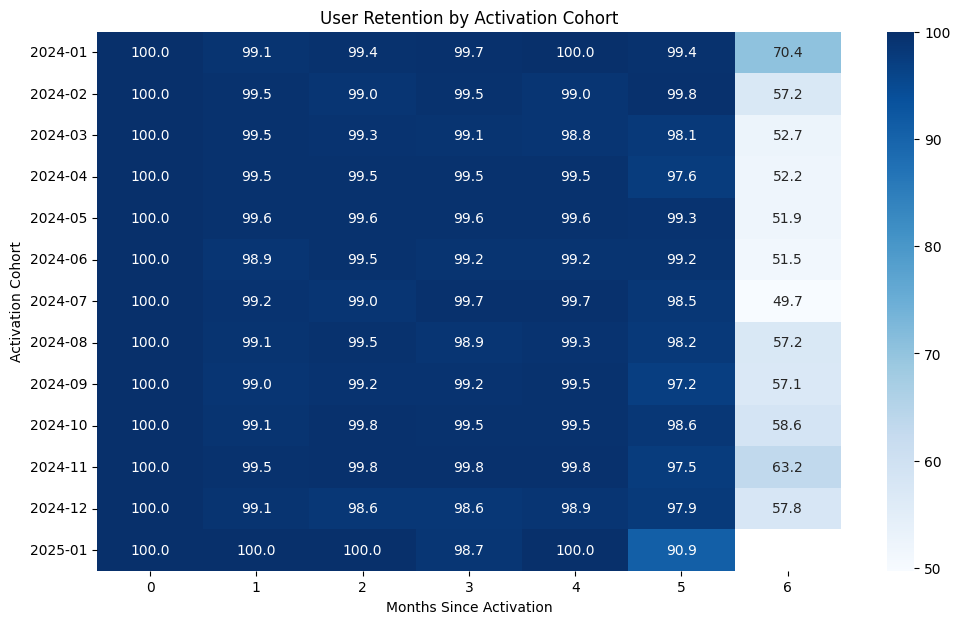

In [223]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.heatmap(
    activation_retention_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("User Retention by Activation Cohort")
plt.xlabel("Months Since Activation")
plt.ylabel("Activation Cohort")
plt.show()

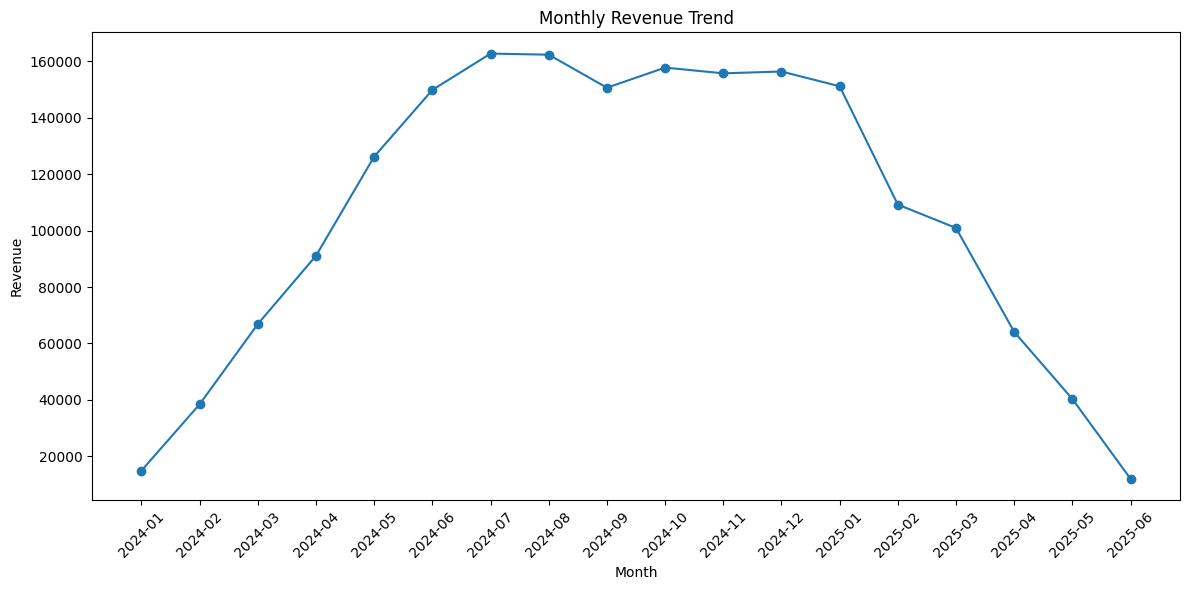

In [202]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

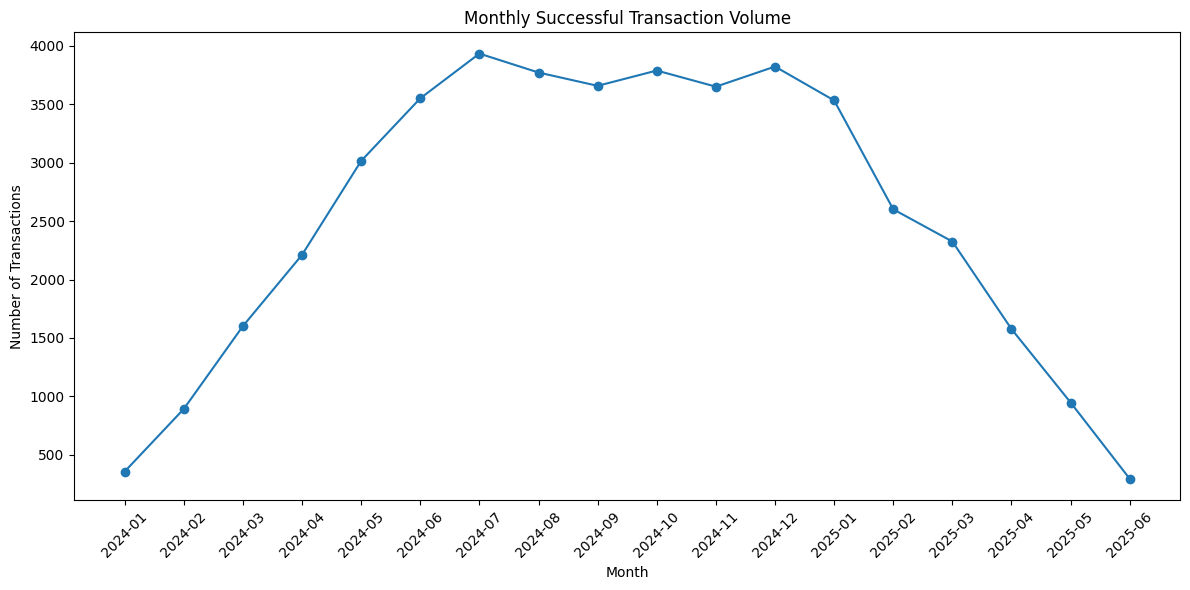

In [203]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values,
    marker="o"
)

plt.title("Monthly Successful Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

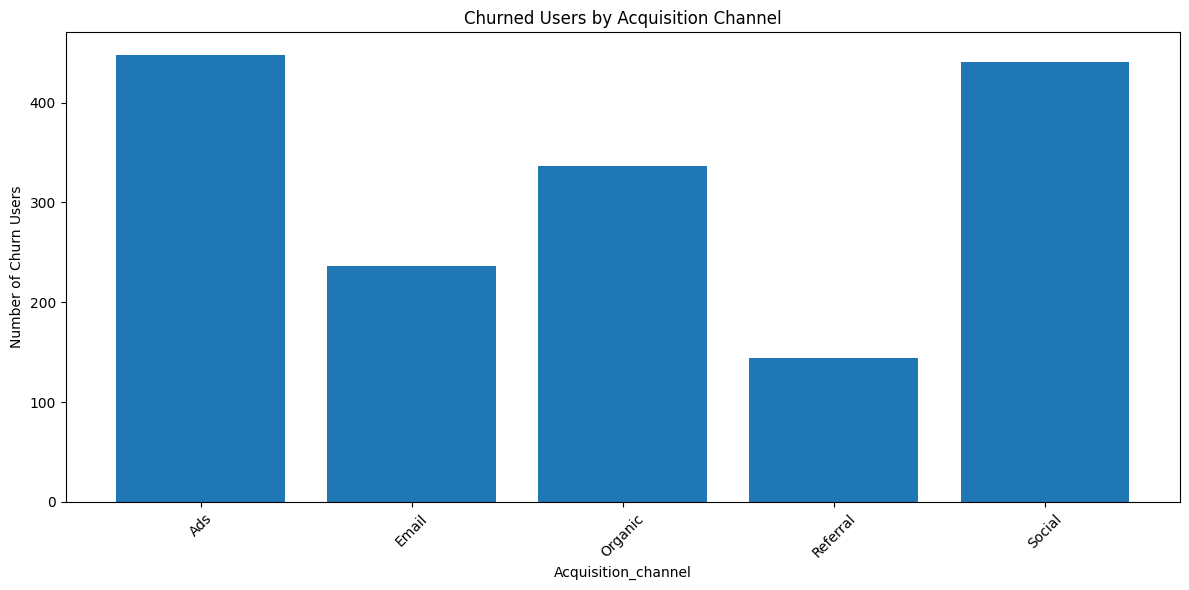

In [208]:
plt.figure(figsize=(12, 6))

plt.bar(
    churned_users_channel.index.astype(str),
    churned_users_channel.values
)

plt.title("Churned Users by Acquisition Channel")
plt.xlabel("Acquisition_channel")
plt.ylabel("Number of Churn Users")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

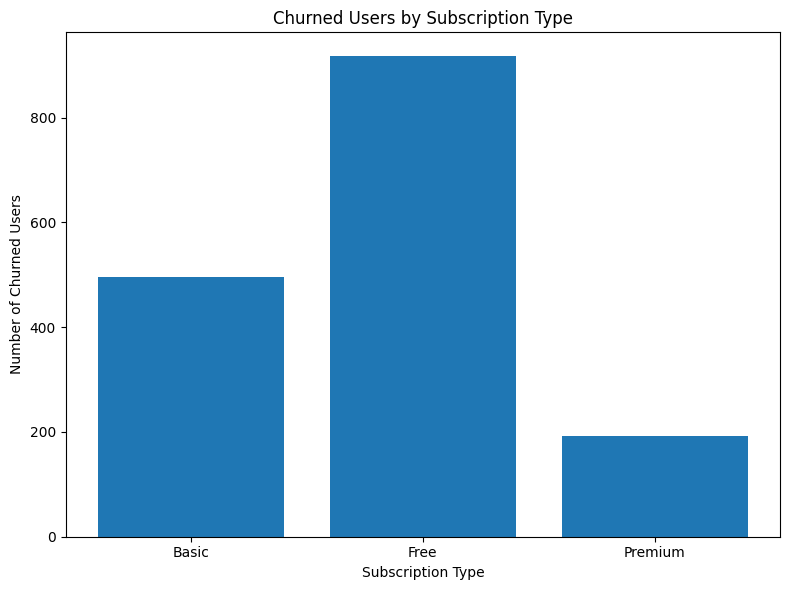

In [217]:
plt.figure(figsize=(8, 6))

plt.bar(
    churned_users_sub.index,
    churned_users_sub.values
)

plt.title("Churned Users by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Churned Users")

plt.tight_layout()
plt.show()

In [221]:
heatmap_data = subscription_channel_matrix["Churn Rate"].unstack()

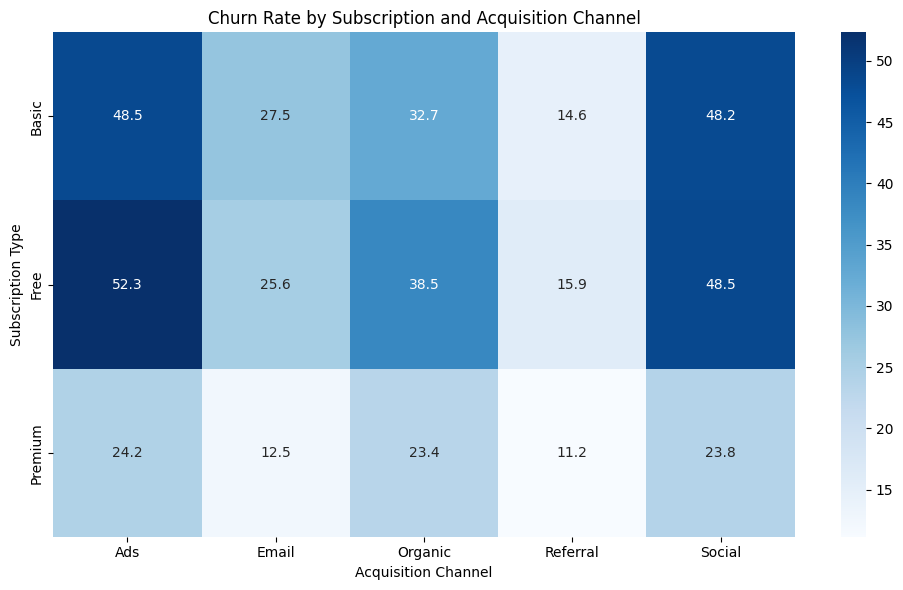

In [222]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Churn Rate by Subscription and Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Subscription Type")

plt.tight_layout()
plt.show()